
# Solar Irradiation — BigQuery Quickstart (Team Notebook)

Welcome! This notebook shows how to use our **BigQuery dataset** and **views** for the solar irradiation project.

## What we have

- **Raw data (GCS / bronze):** Original CSVs in Google Cloud Storage.
- **Native table (BQ / gold):** `irradiance_daily` with harmonized units (kWh/m²/day) and a standard schema.
- **Views (BQ):**
  - `v_irr_monthly_by_point` — monthly averages per grid point (lat/lon, by source).
  - `v_irr_weekly_by_point` — weekly averages per grid point (ISO week, Monday start).
- **Table function (BQ):**
  - `fn_nearest_point(lat, lon, start_date, end_date, max_km)` — for each day in the range, returns the **nearest** grid point per source to a given (lat, lon).

## Key concepts

- A **BigQuery table** stores data; querying it scans bytes.
- A **BigQuery view** stores a SQL definition only (no data copied). Queries against a view read the underlying table(s).
- A **BigQuery external table** points to files in GCS (no copy). We used external tables to **inspect raw CSVs** only.
- Our **native table** `irradiance_daily` *does* store data **inside BigQuery** (fast, partitioned by date).
- The **views** and **table function** live in our BigQuery dataset and don't need to be recreated every time. You only recreate them if you change their SQL.



## Prerequisites

1. **Python packages**
   - `google-cloud-bigquery`
   - `pandas`
   - (optional) `pyarrow` for exports
   - (optional) `matplotlib` for plotting

2. **Authentication**
   - Use **Application Default Credentials (ADC)** on your machine:
     ```bash
     gcloud auth application-default login
     gcloud config set project solar-irradiation-estimation
     ```
   - Or use a **service account key JSON** and set `GOOGLE_APPLICATION_CREDENTIALS` to its path.

3. **Project/Dataset**
   - Project: `solar-irradiation-estimation`
   - Dataset: `solar_warehouse`


In [ ]:
# Optional: install needed libs (uncomment to run)
# %pip install --quiet google-cloud-bigquery pandas pyarrow matplotlib


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import date
from typing import Optional, Sequence

import pandas as pd
from google.cloud import bigquery
from google.cloud.bigquery import ScalarQueryParameter
import matplotlib.pyplot as plt  # Charts: use matplotlib (no seaborn, no styles)

PROJECT_ID: str = "solar-irradiation-estimation"
DATASET: str = "solar_warehouse"
DATASET_FQN: str = f"{PROJECT_ID}.{DATASET}"

print(f"Using dataset: {DATASET_FQN}")

Using dataset: solar-irradiation-estimation.solar_warehouse


In [2]:
def create_client(project: Optional[str] = None) -> bigquery.Client:
    """Create an authenticated BigQuery client using ADC or a service account."""
    return bigquery.Client(project=project or None)


def query_to_dataframe(
    client: bigquery.Client,
    sql: str,
    parameters: Optional[Sequence[ScalarQueryParameter]] = None,
) -> pd.DataFrame:
    """
    Run a (parameterized) query and return results as a pandas DataFrame.

    - Only constructs QueryJobConfig when parameters are provided.
    - Falls back gracefully if the BigQuery Storage client isn't installed.
    """
    job_config: Optional[bigquery.QueryJobConfig] = None
    if parameters:
        job_config = bigquery.QueryJobConfig(query_parameters=list(parameters))

    job: bigquery.job.QueryJob = client.query(sql, job_config=job_config)
    result: bigquery.table.RowIterator = job.result()

    try:
        # Faster if google-cloud-bigquery-storage is installed
        df: pd.DataFrame = result.to_dataframe(create_bqstorage_client=True)
    except Exception:
        df = result.to_dataframe(create_bqstorage_client=False)
    return df


def call_fn_nearest_point(
    client: bigquery.Client,
    dataset_fqn: str,
    *,
    lat: float,
    lon: float,
    start_date: date,
    end_date: date,
    max_km: Optional[float] = 100.0,
) -> pd.DataFrame:
    """Call the table function fn_nearest_point and return daily nearest-point rows."""
    sql = f"""
    SELECT *
    FROM `{dataset_fqn}.fn_nearest_point`(@lat, @lon, @start_date, @end_date, @max_km)
    ORDER BY date, source
    """
    params = [
        ScalarQueryParameter("lat", "FLOAT64", lat),
        ScalarQueryParameter("lon", "FLOAT64", lon),
        ScalarQueryParameter("start_date", "DATE", start_date),
        ScalarQueryParameter("end_date", "DATE", end_date),
        ScalarQueryParameter("max_km", "FLOAT64", max_km),
    ]
    return query_to_dataframe(client, sql, params)


## Connect and list objects
Let's verify that our views and the table function exist in the dataset.


In [3]:
client = create_client(PROJECT_ID)

# List views
sql_views = f"""
SELECT table_name, table_type
FROM `{DATASET_FQN}`.INFORMATION_SCHEMA.TABLES
WHERE table_name IN ('v_irr_monthly_by_point','v_irr_weekly_by_point','v_irr_monthly_all')
ORDER BY table_name
"""
df_views = query_to_dataframe(client, sql_views)
df_views

/home/jan/.pyenv/versions/.venv_irradiation/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,table_name,table_type
0,v_irr_monthly_by_point,VIEW
1,v_irr_weekly_by_point,VIEW


In [4]:
# List table functions
sql_funcs = f"""
SELECT routine_name, routine_type
FROM `{DATASET_FQN}`.INFORMATION_SCHEMA.ROUTINES
WHERE routine_name = 'fn_nearest_point'
"""
df_funcs = query_to_dataframe(client, sql_funcs)
df_funcs

/home/jan/.pyenv/versions/.venv_irradiation/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,routine_name,routine_type
0,fn_nearest_point,TABLE FUNCTION


## Monthly averages for a single location (Kampala)

Use the table function `fn_nearest_point(lat, lon, start_date, end_date, max_km)` to fetch **daily** values for the nearest grid point per source, then aggregate to **monthly** in Python.


In [5]:
from datetime import date
import pandas as pd
from google.cloud.bigquery import ScalarQueryParameter

# Kampala (approximate)
site_lat: float = 0.3476
site_lon: float = 32.5825

start_date: date = date(2024, 1, 1)
end_date: date   = date(2024, 12, 31)

# Fetch daily nearest-grid values per source for Kampala
df_daily_kla: pd.DataFrame = call_fn_nearest_point(
    client,
    DATASET_FQN,
    lat=site_lat,
    lon=site_lon,
    start_date=start_date,
    end_date=end_date,
    max_km=100.0,   # you can shrink this if you prefer a tighter radius
)

# Aggregate to monthly stats per source
df_daily_kla["month"] = pd.to_datetime(df_daily_kla["date"]).dt.to_period("M").dt.to_timestamp()

df_month_kla: pd.DataFrame = (
    df_daily_kla
    .groupby(["source", "month"], as_index=False)["ghi_kwh_m2_day"]
    .agg(ghi_mean="mean", ghi_std="std", days="count")
    .sort_values(["month", "source"])
)

df_month_kla.head()


/home/jan/.pyenv/versions/.venv_irradiation/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,source,month,ghi_mean,ghi_std,days
0,CAMS,2024-01-01,4.402197,1.431759,31
12,NASA,2024-01-01,4.768387,1.133126,31
1,CAMS,2024-02-01,4.935924,1.418231,29
13,NASA,2024-02-01,5.116552,1.010429,29
2,CAMS,2024-03-01,6.216594,1.435365,31



### Plot: NASA vs CAMS monthly GHI means


<Figure size 640x480 with 0 Axes>

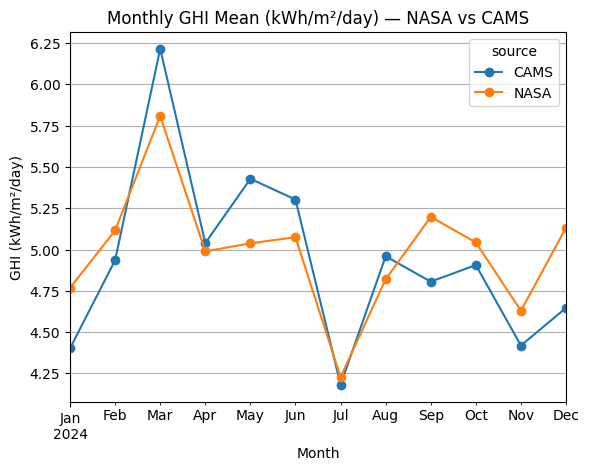

In [6]:
# Pivot for plotting
pivot = df_month_kla.pivot(index="month", columns="source", values="ghi_mean").copy()

# Plot (one chart, no specific colors or styles)
plt.figure()
pivot.plot(marker="o")
plt.title("Monthly GHI Mean (kWh/m²/day) — NASA vs CAMS")
plt.xlabel("Month")
plt.ylabel("GHI (kWh/m²/day)")
plt.grid(True)
plt.show()


## Nearest-point daily values (live lookup)

Use the table function to fetch the *nearest grid point* per source for a given location and date range.


In [7]:
site_lat: float = -1.38214
site_lon: float = 29.671499

df_daily_nearest = call_fn_nearest_point(
    client,
    DATASET_FQN,
    lat=site_lat,
    lon=site_lon,
    start_date=start_date,
    end_date=end_date,
    max_km=50.0,
)
df_daily_nearest.head()

/home/jan/.pyenv/versions/.venv_irradiation/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,source,date,latitude,longitude,ghi_kwh_m2_day,dhi_kwh_m2_day,dni_kwh_m2_day,reliability,distance_m
0,CAMS,2024-01-01,-1.38214,29.671499,3.326575,2.637628,1.256767,0.9826,0.019348
1,NASA,2024-01-01,-1.38214,29.671499,4.400000,2.670000,1.480000,NaN,0.019348
2,CAMS,2024-01-02,-1.38214,29.671499,3.121928,2.682449,0.877616,0.9826,0.019348
3,NASA,2024-01-02,-1.38214,29.671499,3.680000,2.610000,0.540000,NaN,0.019348
4,CAMS,2024-01-03,-1.38214,29.671499,1.963553,1.815554,0.592305,0.9830,0.019348



### Aggregate those daily values to monthly


In [8]:
# Compute monthly averages for the nearest grid point per source
df_daily_nearest['month'] = pd.to_datetime(df_daily_nearest['date']).dt.to_period('M').dt.to_timestamp()
agg = (
    df_daily_nearest.groupby(['source', 'month'], as_index=False)['ghi_kwh_m2_day']
    .mean()
    .rename(columns={'ghi_kwh_m2_day': 'ghi_mean'})
)
agg.head()

,source,month,ghi_mean
0,CAMS,2024-01-01,3.653962
1,CAMS,2024-02-01,4.033853
2,CAMS,2024-03-01,4.731965
3,CAMS,2024-04-01,4.041798
4,CAMS,2024-05-01,4.476984



### Plot: Nearest-point monthly series


<Figure size 640x480 with 0 Axes>

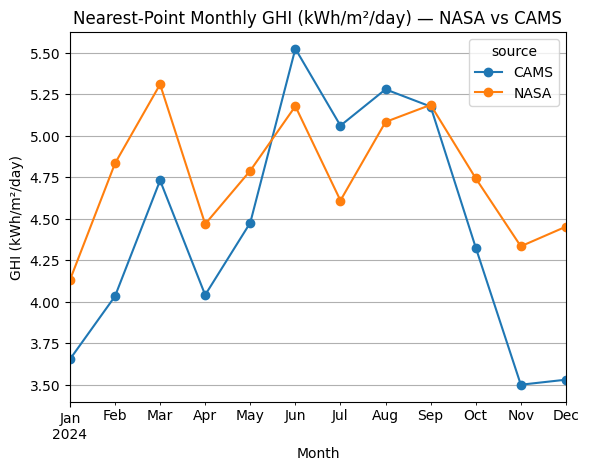

In [9]:
pivot_site = agg.pivot(index="month", columns="source", values="ghi_mean").copy()

plt.figure()
pivot_site.plot(marker="o")
plt.title("Nearest-Point Monthly GHI (kWh/m²/day) — NASA vs CAMS")
plt.xlabel("Month")
plt.ylabel("GHI (kWh/m²/day)")
plt.grid(True)
plt.show()


## Export to Parquet (optional)
If you need to persist a small dataset for training or sharing.


In [ ]:
# Optional export (requires pyarrow)
# df_daily_nearest.to_parquet('nearest_daily_sample.parquet', index=False)
# print("Wrote nearest_daily_sample.parquet")


## Team access & best practices

- **Where are the views?** In BigQuery, under the dataset `solar_warehouse` (EU region). They are persistent and **do not need to be recreated** unless we update their SQL.
- **Where is the data?**
  - `irradiance_daily` is a **native BigQuery table** (data stored in BigQuery).
  - The external tables (for raw CSVs) are pointers to GCS files (no copy); we used them only during ingestion/validation.
- **How to query?** Use the views or the table function from notebooks, scripts, or the portal API. Always **filter by date** to keep query costs tiny.
- **Permissions (for team members):**
  - Minimum to read and run queries: **BigQuery Job User** + **BigQuery Data Viewer** on the project or dataset.
  - If they also need to read raw files through external tables: grant **Storage Object Viewer** on the GCS bucket.
- **Development workflow:**
  - SQL definitions for views/functions are versioned in the repo.
  - Use the small `run_sql.py` helper to deploy SQL (no CLI required).
  - For changes, open a PR; on merge we re-run the SQL to update the objects.
- **Cost hygiene:**
  - Tables are partitioned by date; views aggregate by month/week. Queries should include date filters to prune scanned bytes.
  - Views themselves have negligible storage cost; you pay only for query bytes scanned from the underlying table(s).
